<a href="https://colab.research.google.com/github/priyansh-commits/Deep_Learning/blob/main/enocoder_decoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vaibhavkumar11/hindi-english-parallel-corpus")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hindi-english-parallel-corpus' dataset.
Path to dataset files: /kaggle/input/hindi-english-parallel-corpus


In [2]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download(
    "vaibhavkumar11/hindi-english-parallel-corpus"
)

print("Dataset folder:", path)
print("Files:", os.listdir(path))

Using Colab cache for faster access to the 'hindi-english-parallel-corpus' dataset.
Dataset folder: /kaggle/input/hindi-english-parallel-corpus
Files: ['hindi_english_parallel.csv']


In [3]:
file_path = os.path.join(path, "hindi_english_parallel.csv")

df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Shape: (1561841, 2)
Columns: ['hindi', 'english']


,hindi,english
0,अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें,Give your application an accessibility workout
1,एक्सेर्साइसर पहुंचनीयता अन्वेषक,Accerciser Accessibility Explorer
2,निचले पटल के लिए डिफोल्ट प्लग-इन खाका,The default plugin layout for the bottom panel
3,ऊपरी पटल के लिए डिफोल्ट प्लग-इन खाका,The default plugin layout for the top panel
4,उन प्लग-इनों की सूची जिन्हें डिफोल्ट रूप से नि...,A list of plugins that are disabled by default


In [16]:
df = df.sample(
    n=min(100000, len(df)),
    random_state=42
).reset_index(drop=True)

print("Dataset size:", len(df))

Dataset size: 100000


In [17]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   hindi    100000 non-null  object
 1   english  100000 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB
None
hindi      0
english    0
dtype: int64


In [18]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   hindi    100000 non-null  object
 1   english  100000 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB


In [20]:
df = df[["hindi", "english"]].copy()


df["hindi"] = df["hindi"].astype(str).str.strip()
df["english"] = df["english"].astype(str).str.strip()

df = df[
    (df["hindi"] != "") &
    (df["english"] != "")
]

df = df.drop_duplicates().reset_index(drop=True)

print("Clean dataset size:", len(df))
display(df.head(10))

Clean dataset size: 100000


,hindi,english
0,निकालना,sell
1,ये लोग जो कुछ छिपा कर करते हैं और जो कुछ ज़ाहि...,Surely Allah knows all that they conceal and a...
2,यह कंप्यूटर सिस्टम और उनसे संबंधित डेटा लाइब्र...,The department which contains the computer sys...
3,पेंचदार और घुमावदार,Twists and Turns
4,"हमें अपनी नदियों, विशेषकर पवित्र गंगा की सफाई ...","We also seek assistance to clean our rivers, p..."
5,मीडिया से की जा रही थी.,before the genocide.
6,ई-पेमेंट की पहल से भुगतान में लगने वाला समय कम...,With e-payment initiative the Payment Life Cyc...
7,"क्रोमियम एप्लिकेशन लॉन्चर, क्रोमियम एप्लिकेशन ...",Chromium App Launcher is a standalone platform...
8,मैं हाथ-करघे के विरुद्व नहीं हूं।,I am not against the handloom.
9,चैतन्य के जीवन और काल पर अधिकारी विद्वान ड़ा ब...,"According to Dr. Biman Bihary Majumdar, who is..."


In [21]:
hindi_vectorizer=tf.keras.layers.TextVectorization(
    max_tokens=None,
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    output_mode="int",
    output_sequence_length=22
)
english_vectorizer=tf.keras.layers.TextVectorization(
    max_tokens=None,
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    output_mode="int",
    output_sequence_length=22
)

In [22]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

MAX_LEN = 22

english_text = "<start> " + df["english"] + " <end>"

hindi_vectorizer.adapt(
    tf.data.Dataset.from_tensor_slices(
        df["hindi"].tolist()
    ).batch(256)
)

english_vectorizer.adapt(
    tf.data.Dataset.from_tensor_slices(
        english_text.tolist()
    ).batch(256)
)

X = hindi_vectorizer(
    tf.constant(df["hindi"].tolist())
).numpy()

Y = english_vectorizer(
    tf.constant(english_text.tolist())
).numpy()

decoder_input = Y[:, :-1]
decoder_target = Y[:, 1:]

X_train, X_temp, D_train, D_temp, T_train, T_temp = (
    train_test_split(
        X, decoder_input, decoder_target,
        test_size=0.2, random_state=42
    )
)

X_val, X_test, D_val, D_test, T_val, T_test = (
    train_test_split(
        X_temp, D_temp, T_temp,
        test_size=0.5, random_state=42
    )
)

print(X_train.shape, D_train.shape, T_train.shape)

(80000, 22) (80000, 21) (80000, 21)


In [23]:
from tensorflow.keras.layers import Embedding, Input

In [24]:
import numpy as np
from sklearn.model_selection import train_test_split

X = hindi_vectorizer(
    tf.constant(df["hindi"].tolist())
).numpy()

Y = english_vectorizer(
    tf.constant(english_text.tolist())
).numpy()

# Decoder input excludes the last token
decoder_input = Y[:, :-1]

# Target excludes the first token
decoder_target = Y[:, 1:]

X_train, X_temp, D_train, D_temp, T_train, T_temp = (
    train_test_split(
        X, decoder_input, decoder_target,
        test_size=0.2, random_state=42
    )
)

X_val, X_test, D_val, D_test, T_val, T_test = (
    train_test_split(
        X_temp, D_temp, T_temp,
        test_size=0.5, random_state=42
    )
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 80000
Validation samples: 10000
Test samples: 10000


In [25]:
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Embedding, LSTM, Dense

EMBED_DIM = 64
LATENT_DIM = 128
BATCH_SIZE = 128

hindi_vocab_size = len(hindi_vectorizer.get_vocabulary())
english_vocab_size = len(english_vectorizer.get_vocabulary())

# Encoder
encoder_inputs = Input(shape=(MAX_LEN,), name="hindi_input")

encoder_embedding = Embedding(
    hindi_vocab_size, EMBED_DIM, mask_zero=False
)(encoder_inputs)

encoder_lstm = LSTM(
    LATENT_DIM, return_state=True
)

_, state_h, state_c = encoder_lstm(encoder_embedding)

encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(
    shape=(MAX_LEN - 1,), name="english_input"
)

decoder_embedding_layer = Embedding(
    english_vocab_size, EMBED_DIM, mask_zero=False
)

decoder_embedded = decoder_embedding_layer(decoder_inputs)

decoder_lstm = LSTM(
    LATENT_DIM, return_sequences=True, return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedded, initial_state=encoder_states
)

decoder_dense = Dense(english_vocab_size, activation="softmax")
outputs = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], outputs)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ hindi_input         │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ english_input       │ (None, 21)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 22, 64)    │  5,912,768 │ hindi_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 21, 64)    │  3,799,744 │ english_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 128),     │     98,816 │ embedding_2[0][0] │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, 21, 128), │     98,816 │ embedding_3[0][0… │
│                     │ (None, 128),      │            │ lstm_2[0][1],     │
│                     │ (None, 128)]      │            │ lstm_2[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 21, 59371) │  7,658,859 │ lstm_3[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 17,569,003 (67.02 MB)

 Trainable params: 17,569,003 (67.02 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "/content/best_translation.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    [X_train, D_train],
    T_train,
    validation_data=([X_val, D_val], T_val),
    batch_size=128,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 198s 315ms/step - loss: 4.1259 - sparse_categorical_accuracy: 0.5112 - val_loss: 3.6562 - val_sparse_categorical_accuracy: 0.5357
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 196s 313ms/step - loss: 3.4693 - sparse_categorical_accuracy: 0.5518 - val_loss: 3.4834 - val_sparse_categorical_accuracy: 0.5481
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 196s 314ms/step - loss: 3.2865 - sparse_categorical_accuracy: 0.5652 - val_loss: 3.3685 - val_sparse_categorical_accuracy: 0.5589
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 196s 314ms/step - loss: 3.1554 - sparse_categorical_accuracy: 0.5736 - val_loss: 3.2933 - val_sparse_categorical_accuracy: 0.5641
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 196s 313ms/step - loss: 3.0454 - sparse_categorical_accuracy: 0.5795 - val_loss: 3.2395 - val_sparse_categorical_accuracy: 0.5672


In [30]:
import numpy as np

train_weights = (T_train != 0).astype("float32")
val_weights = (T_val != 0).astype("float32")

print("Training weights:", train_weights.shape)
print("Validation weights:", val_weights.shape)

Training weights: (80000, 21)
Validation weights: (10000, 21)


In [27]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy"
)

In [32]:
history_more = model.fit(
    [X_train, D_train],
    T_train,
    validation_data=([X_val, D_val], T_val),
    batch_size=128,
    epochs=3,
    callbacks=callbacks,
    sample_weight=train_weights,
    # validation_sample_weight=val_weights
)

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 197s 313ms/step - loss: 2.8686 - sparse_categorical_accuracy: 0.5693 - val_loss: 3.3831 - val_sparse_categorical_accuracy: 0.5324
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 195s 312ms/step - loss: 2.7695 - sparse_categorical_accuracy: 0.4713 - val_loss: 3.9447 - val_sparse_categorical_accuracy: 0.2974


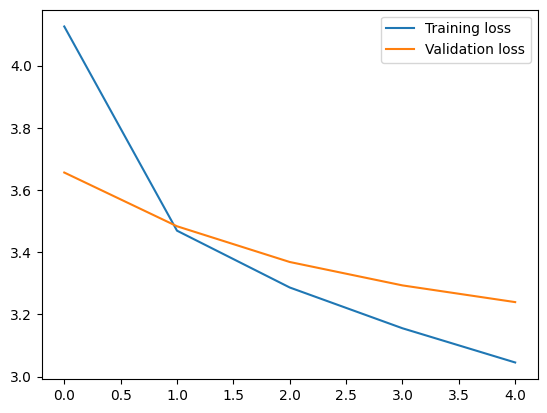

In [33]:
from matplotlib import pyplot as plt

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.legend()
plt.show()

In [34]:
encoder_model = Model(
    encoder_inputs,
    encoder_states
)

print("Encoder inference model ready!")

Encoder inference model ready!


In [35]:
import tensorflow as tf
from tensorflow.keras import Model, Input

decoder_state_h = Input(shape=(LATENT_DIM,))
decoder_state_c = Input(shape=(LATENT_DIM,))
decoder_token = Input(shape=(1,))

decoder_x = decoder_embedding_layer(decoder_token)

decoder_y, next_h, next_c = decoder_lstm(
    decoder_x,
    initial_state=[decoder_state_h, decoder_state_c]
)

decoder_probs = decoder_dense(decoder_y)

decoder_model = Model(
    [decoder_token, decoder_state_h, decoder_state_c],
    [decoder_probs, next_h, next_c]
)

print("Decoder inference model ready!")

Decoder inference model ready!


In [36]:
def translate(sentence):
    source = hindi_vectorizer(
        tf.constant([sentence])
    ).numpy()

    states = encoder_model.predict(source, verbose=0)

    token = START_ID
    result = []

    for _ in range(MAX_LEN):
        probs, h, c = decoder_model.predict(
            [np.array([[token]]), *states],
            verbose=0
        )

        token = int(np.argmax(probs[0, 0]))
        states = [h, c]

        if token == END_ID or token == 0:
            break

        result.append(eng_vocab[token])

    return " ".join(result)

In [37]:
eng_vocab = english_vectorizer.get_vocabulary()

print(eng_vocab[:30])
print("start exists:", "start" in eng_vocab)
print("end exists:", "end" in eng_vocab)

['', '[UNK]', np.str_('end'), np.str_('start'), np.str_('the'), np.str_('of'), np.str_('and'), np.str_('to'), np.str_('in'), np.str_('a'), np.str_('is'), np.str_('for'), np.str_('that'), np.str_('you'), np.str_('it'), np.str_('be'), np.str_('he'), np.str_('not'), np.str_('they'), np.str_('with'), np.str_('are'), np.str_('on'), np.str_('or'), np.str_('as'), np.str_('this'), np.str_('by'), np.str_('we'), np.str_('from'), np.str_('have'), np.str_('was')]
start exists: True
end exists: True


In [38]:
eng_word_to_id = {
    word: i for i, word in enumerate(eng_vocab)
}

START_ID = eng_word_to_id["start"]
END_ID = eng_word_to_id["end"]

print("START_ID:", START_ID)
print("END_ID:", END_ID)

START_ID: 3
END_ID: 2


In [40]:
print(translate("मेरा नाम प्रियंश है"))
print(translate("मैं स्कूल जा रहा हूँ"))
print(translate("भारत एक बड़ा देश है"))
print(translate("आप कैसे हैं"))

i m going to get a
i m going to get a
the president of the country
i m going to get a


In [42]:
for i in range(5):
    print("Hindi:", df["hindi"].iloc[i])
    print("English:", df["english"].iloc[i])
    print()

Hindi: निकालना
English: sell

Hindi: ये लोग जो कुछ छिपा कर करते हैं और जो कुछ ज़ाहिर बज़ाहिर करते हैं (ग़रज़ सब कुछ) ख़ुदा ज़रुर जानता है वह हरगिज़ तकब्बुर करने वालों को पसन्द नहीं करता
English: Surely Allah knows all that they conceal and all that they disclose. He certainly does not love those who are steeped in arrogance.

Hindi: यह कंप्यूटर सिस्टम और उनसे संबंधित डेटा लाइब्ररि सहित उपकरणों से संबधित विभाग है।
English: The department which contains the computer systems and related equipment, including the data library.

Hindi: पेंचदार और घुमावदार
English: Twists and Turns

Hindi: हमें अपनी नदियों, विशेषकर पवित्र गंगा की सफाई करने के लिए भी सहायता चाहिए।
English: We also seek assistance to clean our rivers, particularly the holy Ganga.



In [41]:
print("Hindi example:")
print(df["hindi"].iloc[0])

print("\nEnglish example:")
print(df["english"].iloc[0])

print("\nHindi tokenized:")
print(hindi_vectorizer(df["hindi"].iloc[0:1]).numpy())

print("\nEnglish tokenized:")
print(english_vectorizer(
    ["<start> " + df["english"].iloc[0] + " <end>"]
).numpy())
print("Hindi vocabulary:", len(hindi_vectorizer.get_vocabulary()))
print("English vocabulary:", len(english_vectorizer.get_vocabulary()))
print("MAX_LEN:", MAX_LEN)
print("Training examples:", len(X_train))

Hindi example:
निकालना

English example:
sell

Hindi tokenized:
[[4043    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]]

English tokenized:
[[   3 2867    2    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]]
Hindi vocabulary: 92387
English vocabulary: 59371
MAX_LEN: 22
Training examples: 80000


better ouput can be generated with larger data and more epochs